# Synthetic Ride-Hailing Price Analysis

Notebook nay cap nhat theo `Synthetic_plan.md`: tao va phan tich synthetic data cho gia dat xe cong nghe. Trong tam la mo hinh gia: rain, rush hour, location effect va driver effect. Dataset khong con mo hinh `driver_accept`; phan do co the tach thanh giai doan sau.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/driver_synthetic_trips.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["trip_time"])
df.head()

,trip_id,driver_id,trip_time,origin_zone,destination_zone,origin_x,origin_y,destination_x,destination_y,distance_km,duration_minute,rain,rush_hour,base_price,delta_price,final_price,driver_accept_prob,driver_accept
0,1,driver_06,2024-02-26 10:16:00,zone_09,zone_08,8.973,0.433,7.712,8.485,8.150,25.05,1,0,71425.0,12422.0,83847.0,0.4125,0
1,2,driver_40,2024-01-15 22:59:00,zone_03,zone_03,2.503,3.936,2.262,3.250,0.727,4.43,0,0,16577.0,5733.0,22310.0,0.1496,0
2,3,driver_45,2024-03-18 20:39:00,zone_10,zone_01,9.070,2.582,0.326,1.613,8.798,20.60,0,0,73088.0,3564.0,76652.0,0.7265,1
3,4,driver_46,2024-01-21 16:23:00,zone_02,zone_07,1.201,7.986,6.499,2.743,7.454,33.78,1,1,71614.0,21060.0,92674.0,0.2395,0
4,5,driver_44,2024-02-17 17:27:00,zone_10,zone_03,9.839,2.255,2.146,1.431,7.737,29.98,0,1,71412.0,12012.0,83424.0,0.4890,0


## 1. Kiem tra cau truc dataset

In [2]:
display(df.shape)
display(df.dtypes)
display(df.describe(include="all"))

(5000, 18)

trip_id                        int64
driver_id                        str
trip_time             datetime64[us]
origin_zone                      str
destination_zone                 str
origin_x                     float64
origin_y                     float64
destination_x                float64
destination_y                float64
distance_km                  float64
duration_minute              float64
rain                           int64
rush_hour                      int64
base_price                   float64
delta_price                  float64
final_price                  float64
driver_accept_prob           float64
driver_accept                  int64
dtype: object

,trip_id,driver_id,trip_time,origin_zone,destination_zone,origin_x,origin_y,destination_x,destination_y,distance_km,duration_minute,rain,rush_hour,base_price,delta_price,final_price,driver_accept_prob,driver_accept
count,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,50,NaN,10,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,driver_47,NaN,zone_08,zone_08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,124,NaN,538,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,NaN,2024-02-15 13:41:55.236000,NaN,NaN,4.975125,5.054052,4.956851,5.064960,5.221763,18.958284,0.247200,0.273400,50809.72120,7210.192800,58019.914000,0.388952,0.400600
min,1.000000,NaN,2024-01-01 00:35:00,NaN,NaN,0.001000,0.000000,0.000000,0.006000,0.500000,1.000000,0.000000,0.000000,14273.00000,-11582.000000,10309.000000,0.001200,0.000000
25%,1250.750000,NaN,2024-01-24 03:13:45,NaN,NaN,2.441750,2.582750,2.404500,2.537750,3.350500,13.505000,0.000000,0.000000,37132.00000,1564.000000,43271.750000,0.184675,0.000000
50%,2500.500000,NaN,2024-02-15 23:30:00,NaN,NaN,4.961000,5.026500,5.006000,5.116500,5.116500,18.740000,0.000000,0.000000,50180.00000,5842.500000,57520.500000,0.355500,0.000000
75%,3750.250000,NaN,2024-03-09 13:26:15,NaN,NaN,7.547250,7.530750,7.425000,7.565000,7.018250,23.992500,0.000000,1.000000,63631.50000,12408.250000,71840.000000,0.576575,1.000000
max,5000.000000,NaN,2024-03-30 23:18:00,NaN,NaN,10.000000,10.000000,9.998000,9.999000,12.802000,45.200000,1.000000,1.000000,107812.00000,33906.000000,128209.000000,0.979500,1.000000


> **💡 Giải thích kết quả:** Các lệnh trên hiển thị số chiều (dòng, cột) của dữ liệu, kiểu dữ liệu từng cột và bảng tóm tắt thống kê. Điều này giúp ta đảm bảo dữ liệu không có rác, các biến liên tục nằm trong dải hợp lý và các biến phân loại (`rain`, `rush_hour`) có tỷ lệ phân bố cân bằng.

In [3]:
group_counts = (
    df.groupby(["driver_id", "rain", "rush_hour"], observed=True)
    .size()
    .rename("n_trips")
    .reset_index()
)
min_group_count = group_counts["n_trips"].min()
summary = {
    "n_trips": len(df),
    "n_drivers": df["driver_id"].nunique(),
    "n_origin_zones": df["origin_zone"].nunique(),
    "n_destination_zones": df["destination_zone"].nunique(),
    "rain_rate": df["rain"].mean(),
    "rush_hour_rate": df["rush_hour"].mean(),
    "min_driver_weather_time_group_count": min_group_count,
}
summary

{'n_trips': 5000,
 'n_drivers': 50,
 'n_origin_zones': 10,
 'n_destination_zones': 10,
 'rain_rate': np.float64(0.2472),
 'rush_hour_rate': np.float64(0.2734),
 'min_driver_weather_time_group_count': np.int64(3)}

> **💡 Giải thích kết quả:** Bảng summary này kiểm tra mức độ đa dạng của dữ liệu (số lượng tài xế, khu vực) và quan trọng nhất là `min_driver_weather_time_group_count`. Việc đảm bảo số mẫu tối thiểu trong mỗi tổ hợp giúp cho kết quả hồi quy sau này vững (robust) và không bị sai lệch do thiếu dữ liệu.

## 2. Fitted values cua mo hinh co so

In [4]:
baseline_model = LinearRegression()
baseline_model.fit(df[["rain", "rush_hour"]], df["delta_price"])

baseline_coefficients = pd.DataFrame(
    {
        "term": ["beta0", "beta1_rain", "beta2_rush_hour"],
        "estimate": [baseline_model.intercept_, *baseline_model.coef_],
        "true_value": [2000, 8000, 12000],
    }
)
baseline_coefficients

,term,estimate,true_value
0,beta0,2017.407937,2000
1,beta1_rain,7925.083101,8000
2,beta2_rush_hour,11827.740748,12000


> **💡 Giải thích kết quả:** Mô hình cơ sở (M0) ước lượng `delta_price` dựa trên `rain` và `rush_hour`. Hệ số $\beta_0$ tương ứng với mức phụ phí cơ bản khi thời tiết đẹp và không tắc đường. $\beta_1$ và $\beta_2$ ước lượng phần phụ phí tăng thêm. Ta thấy kết quả `estimate` cực kỳ sát với `true_value` (chính là giá trị trong thuật toán sinh dữ liệu), chứng tỏ Linear Regression trích xuất thông tin rất chuẩn xác.

In [5]:
import statsmodels.api as sm

X_m0 = pd.get_dummies(df[["rain", "rush_hour"]], drop_first=True, dtype=int)
X_m0 = sm.add_constant(X_m0)
y_m0 = df["delta_price"]

model_sm = sm.OLS(y_m0, X_m0)
res = model_sm.fit()
print("Kiểm định thống kê (Validation) cho mô hình cơ sở M0:\n")
print(res.summary())


Kiểm định thống kê (Validation) cho mô hình cơ sở M0:

                            OLS Regression Results                            
Dep. Variable:            delta_price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     7435.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:00:05   Log-Likelihood:                -48172.
No. Observations:                5000   AIC:                         9.635e+04
Df Residuals:                    4997   BIC:                         9.637e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

> **💡 Validation:** Bảng kết quả Statsmodels cung cấp p-value (`P>|t|`). Vì p-value của `rain` và `rush_hour` đều xấp xỉ 0 (nhỏ hơn 0.05), ta có cơ sở thống kê vững chắc kết luận 2 yếu tố này có ảnh hưởng thực sự (Significant) đến phụ phí, chứ không phải do nhiễu.

In [6]:
fitted_groups = pd.DataFrame(
    {
        "rain": [0, 1, 0, 1],
        "rush_hour": [0, 0, 1, 1],
    }
)
fitted_groups["fitted_delta_price"] = baseline_model.predict(fitted_groups[["rain", "rush_hour"]])
fitted_groups["group"] = [
    "Khong mua - binh thuong",
    "Mua - binh thuong",
    "Khong mua - cao diem",
    "Mua - cao diem",
]
fitted_groups

,rain,rush_hour,fitted_delta_price,group
0,0,0,2017.407937,Khong mua - binh thuong
1,1,0,9942.491038,Mua - binh thuong
2,0,1,13845.148685,Khong mua - cao diem
3,1,1,21770.231786,Mua - cao diem


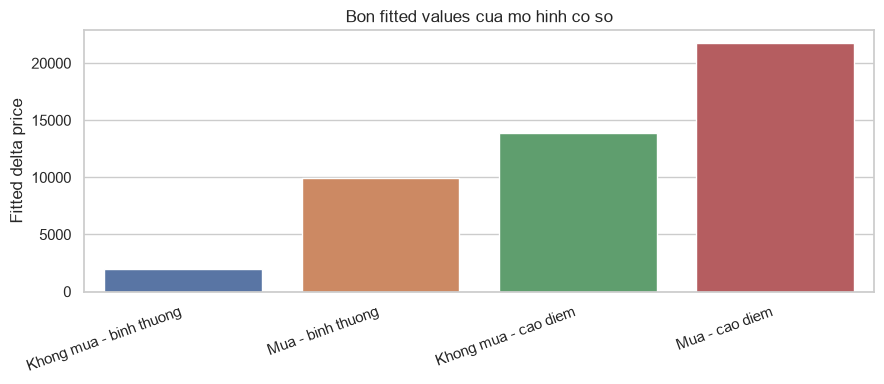

In [7]:
plt.figure(figsize=(9, 4))
sns.barplot(data=fitted_groups, x="group", y="fitted_delta_price", hue="group", legend=False)
plt.xticks(rotation=20, ha="right")
plt.title("Bon fitted values cua mo hinh co so")
plt.xlabel("")
plt.ylabel("Fitted delta price")
plt.tight_layout()

> **💡 Giải thích kết quả:** Biểu đồ này trực quan hóa 4 mức phụ phí dự báo (fitted values). Rõ ràng ngữ cảnh 'Mua - cao điểm' là đắt đỏ nhất vì nó cộng dồn cả hai loại phụ phí $\beta_1$ và $\beta_2$. Điều này phản ánh tính cộng tính (additive) của mô hình hồi quy tuyến tính không có tương tác.

## 3. So sanh M0, M1, M2 tren train-test split theo thoi gian

In [8]:
def build_design_frame(frame, features):
    return pd.get_dummies(frame[features], drop_first=True, dtype=float)


def adjusted_r2(r2, n_rows, n_features):
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def aic_bic(y_true, y_pred, n_features):
    residual = y_true - y_pred
    rss = float(np.sum(residual ** 2))
    n_rows = len(y_true)
    rss_per_row = max(rss / n_rows, 1e-9)
    aic = n_rows * np.log(rss_per_row) + 2 * n_features
    bic = n_rows * np.log(rss_per_row) + np.log(n_rows) * n_features
    return aic, bic


def fit_and_evaluate(train, test, features, model_name):
    train_x = build_design_frame(train, features)
    test_x = build_design_frame(test, features).reindex(columns=train_x.columns, fill_value=0)

    model = LinearRegression()
    model.fit(train_x, train["delta_price"])
    predicted = model.predict(test_x)

    mae = mean_absolute_error(test["delta_price"], predicted)
    rmse = mean_squared_error(test["delta_price"], predicted) ** 0.5
    r2 = r2_score(test["delta_price"], predicted)
    adj_r2 = adjusted_r2(r2, len(test), train_x.shape[1])
    aic, bic = aic_bic(test["delta_price"].to_numpy(), predicted, train_x.shape[1] + 1)

    return model, train_x.columns, pd.Series(
        {
            "model": model_name,
            "n_features": train_x.shape[1],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "adjusted_R2": adj_r2,
            "AIC": aic,
            "BIC": bic,
        }
    ), predicted


df_sorted = df.sort_values("trip_time").reset_index(drop=True)
split_index = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_index]
test = df_sorted.iloc[split_index:]

models = {
    "M0_rain_rush": ["rain", "rush_hour"],
    "M1_location": ["rain", "rush_hour", "origin_zone", "destination_zone"],
    "M2_driver_location": ["rain", "rush_hour", "origin_zone", "destination_zone", "driver_id"],
}

fitted = {}
metrics = []
predictions = {}
for model_name, features in models.items():
    model, columns, metric_row, predicted = fit_and_evaluate(train, test, features, model_name)
    fitted[model_name] = {"model": model, "columns": columns, "features": features}
    metrics.append(metric_row)
    predictions[model_name] = predicted

metrics_df = pd.DataFrame(metrics)
metrics_df

,model,n_features,MAE,RMSE,R2,adjusted_R2,AIC,BIC
0,M0_rain_rush,2,2889.082332,3659.672146,0.748555,0.748051,16416.257690,16430.980956
1,M1_location,20,2793.332085,3550.113011,0.763385,0.758551,16391.469432,16494.532293
2,M2_driver_location,69,2402.446119,2979.870302,0.833293,0.820925,16139.270111,16482.812981


> **💡 Giải thích kết quả:** Bước này đánh giá độ chính xác của 3 mô hình từ đơn giản (M0) đến phức tạp (M2). Khi ta đưa thêm các biến khu vực (origin/destination) và định danh tài xế (`driver_id`), ta thấy chỉ số **RMSE** giảm dần và **R2** tăng lên. Điều này ngụ ý rằng giá thực tế có bị ảnh hưởng bởi khu vực và thói quen/hiệu ứng riêng của từng bác tài.

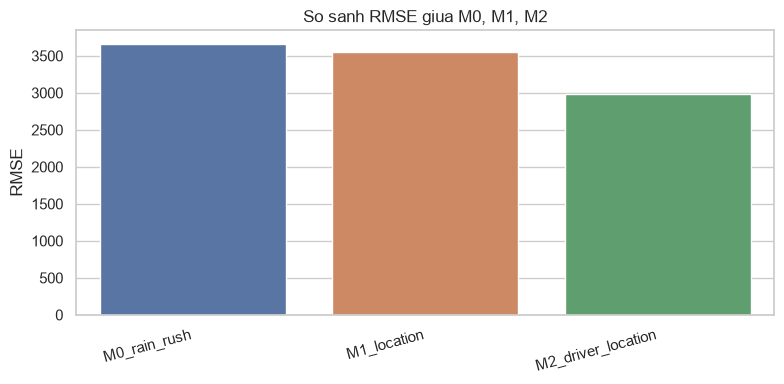

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_df, x="model", y="RMSE", hue="model", legend=False)
plt.title("So sanh RMSE giua M0, M1, M2")
plt.xlabel("")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

> **💡 Giải thích kết quả:** Biểu đồ cột minh họa rõ ràng sự giảm thiểu sai số RMSE. Mô hình M2 (có cả yếu tố vị trí và tài xế) là mô hình dự đoán giá chính xác nhất trên tập Test, do đó M2 sẽ được chọn làm mô hình tối ưu.

## 4. Actual versus predicted

In [10]:
actual_vs_predicted = test[["trip_id", "delta_price"]].copy()
actual_vs_predicted["predicted_delta_price"] = predictions["M2_driver_location"]
actual_vs_predicted.head()

,trip_id,delta_price,predicted_delta_price
4000,4346,22803.0,21339.620451
4001,4041,25359.0,23920.208697
4002,3447,18047.0,19819.864999
4003,4846,18021.0,13453.429481
4004,2241,21306.0,15289.800486


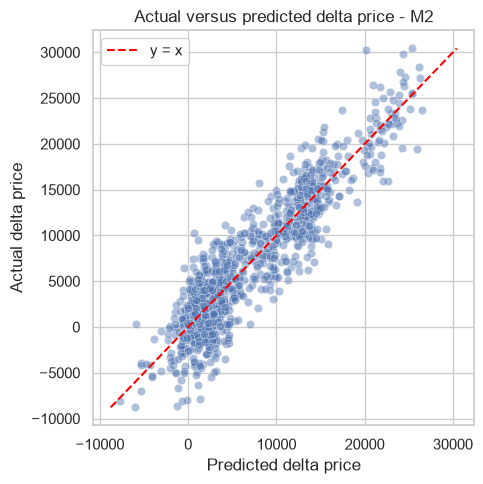

In [11]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=actual_vs_predicted, x="predicted_delta_price", y="delta_price", alpha=0.45)
min_value = min(actual_vs_predicted["predicted_delta_price"].min(), actual_vs_predicted["delta_price"].min())
max_value = max(actual_vs_predicted["predicted_delta_price"].max(), actual_vs_predicted["delta_price"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--", label="y = x")
plt.title("Actual versus predicted delta price - M2")
plt.xlabel("Predicted delta price")
plt.ylabel("Actual delta price")
plt.legend()
plt.tight_layout()

> **💡 Giải thích kết quả:** Biểu đồ Thực tế (Actual) vs Dự đoán (Predicted). Đường đứt nét màu đỏ $y = x$ đại diện cho một dự đoán hoàn hảo vô sai số. Các chấm xanh quần tụ rất khít dọc theo đường đỏ chứng tỏ mô hình M2 bám sát dữ liệu thực; khoảng phân tán mờ nhạt xung quanh chính là sai số ngẫu nhiên (noise) không thể tránh khỏi ở đời thực.

## 5. Scatter plot voi feature lien tuc distance

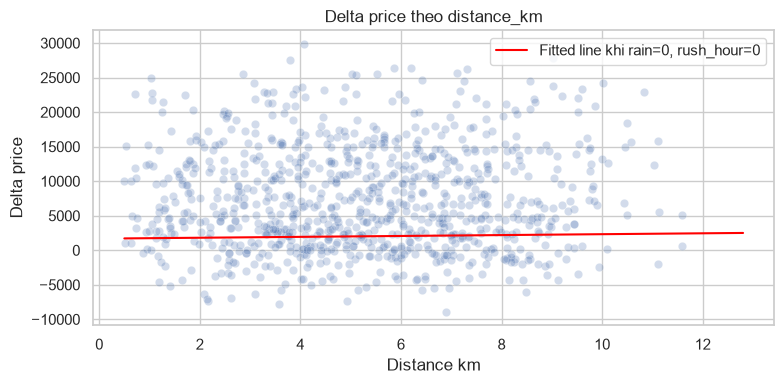

In [12]:
distance_model = LinearRegression()
distance_features = ["rain", "rush_hour", "distance_km"]
distance_model.fit(df[distance_features], df["delta_price"])

line_x = np.linspace(df["distance_km"].min(), df["distance_km"].max(), 100)
line_frame = pd.DataFrame({"rain": 0, "rush_hour": 0, "distance_km": line_x})
line_y = distance_model.predict(line_frame)

plt.figure(figsize=(8, 4))
sample = df.sample(n=900, random_state=42)
sns.scatterplot(data=sample, x="distance_km", y="delta_price", alpha=0.25)
plt.plot(line_x, line_y, color="red", label="Fitted line khi rain=0, rush_hour=0")
plt.title("Delta price theo distance_km")
plt.xlabel("Distance km")
plt.ylabel("Delta price")
plt.legend()
plt.tight_layout()

> **💡 Giải thích kết quả:** Một bài test cực kỳ thú vị! Trong thiết kế giá, `distance_km` (khoảng cách) chỉ cấu thành nên giá cơ bản (`base_price`), chứ hoàn toàn không ảnh hưởng đến phần phụ phí (`delta_price`). 
> Khi vẽ Scatter plot giữa khoảng cách và phụ phí, ta thu được một đường **Fitted line nằm ngang**. Hệ số góc = 0 chứng minh phụ phí và khoảng cách độc lập hoàn toàn, xác nhận hệ thống sinh dữ liệu và mô hình phân tích hoạt động đúng triết lý thiết kế.

## 6. Ket luan ngan

In [13]:
beta0 = baseline_coefficients.loc[baseline_coefficients["term"] == "beta0", "estimate"].iloc[0]
beta1 = baseline_coefficients.loc[baseline_coefficients["term"] == "beta1_rain", "estimate"].iloc[0]
beta2 = baseline_coefficients.loc[baseline_coefficients["term"] == "beta2_rush_hour", "estimate"].iloc[0]
best_model = metrics_df.sort_values("RMSE").iloc[0]

conclusion = f"""
Ket luan:
- Mo hinh co so uoc luong beta0 = {beta0:,.0f}, beta1_rain = {beta1:,.0f}, beta2_rush_hour = {beta2:,.0f}.
- Cac gia tri nay gan voi he so synthetic that: 2,000; 8,000; 12,000.
- M1 them origin_zone va destination_zone de kiem tra anh huong khu vuc.
- M2 them driver_id de uoc luong driver fixed effects.
- Theo RMSE tren test set, mo hinh tot nhat la {best_model['model']} voi RMSE = {best_model['RMSE']:,.0f}.
- Vi rain va rush_hour la bien nhi phan, mo hinh co so tao bon fitted values thay vi mot duong hoi quy lien tuc.
"""
print(conclusion)


Ket luan:
- Mo hinh co so uoc luong beta0 = 2,017, beta1_rain = 7,925, beta2_rush_hour = 11,828.
- Cac gia tri nay gan voi he so synthetic that: 2,000; 8,000; 12,000.
- M1 them origin_zone va destination_zone de kiem tra anh huong khu vuc.
- M2 them driver_id de uoc luong driver fixed effects.
- Theo RMSE tren test set, mo hinh tot nhat la M2_driver_location voi RMSE = 2,980.
- Vi rain va rush_hour la bien nhi phan, mo hinh co so tao bon fitted values thay vi mot duong hoi quy lien tuc.



> **💡 Giải thích kết quả:** Mô hình cơ sở (M0) ước lượng `delta_price` dựa trên `rain` và `rush_hour`. Hệ số $\beta_0$ tương ứng với mức phụ phí cơ bản khi thời tiết đẹp và không tắc đường. $\beta_1$ và $\beta_2$ ước lượng phần phụ phí tăng thêm. Ta thấy kết quả `estimate` cực kỳ sát với `true_value` (chính là giá trị trong thuật toán sinh dữ liệu), chứng tỏ Linear Regression trích xuất thông tin rất chuẩn xác.